# best3-disagreement — Model Selection: XGBoost vs CatBoost vs Random Forest

All three models are competitive in Model_Comparison_Final. This notebook makes the final call using:
1. **Paired t-test** on 5-fold CV AUCs — are differences statistically real or noise?
2. **Lift curves** — which model finds more hitmakers at each screening threshold?
3. **Disagreement analysis** — where do models split, and who is right?
4. **Summary recommendation**

Models use their **Model_Comparison_Final final params** (no re-tuning).  
CatBoost uses the **dedicated nb18 Mid params** (n=12, 100-trial Optuna), not the pipeline version.

| Model | Test AUC | Gap | Recall | F1 | Leaves |
|---|---|---|---|---|---|
| XGBoost | 0.774 | −0.003 | 0.727 | 0.686 | 468 |
| Random Forest | 0.767 | +0.005 | 0.758 | 0.680 | 1590 |
| CatBoost (pipeline) | 0.753 | +0.021 | 0.697 | 0.639 | 1430 |
| **CatBoost (dedicated)** | **0.770** | **+0.021** | **0.773** | **0.680** | **400** |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
N_SPLITS     = 5

In [2]:
# Data loading — identical to Model_Comparison_Final.
df = pd.read_csv('../df_artists_final.csv', index_col=0).reset_index()
X_raw = df.drop(columns=['top_20_hitmaker'])
y     = df['top_20_hitmaker']

ALL_GENRE_COLS = [c for c in X_raw.columns if c.startswith('artist_genre_')]

def add_genre_other(df_imp, keep_genres):
    """Sum low-signal genre dummies into artist_genre_other."""
    keep_full  = [f'artist_genre_{g}' if not g.startswith('artist_genre_') else g
                  for g in keep_genres]
    low_signal = [c for c in ALL_GENRE_COLS if c not in keep_full]
    out = df_imp.copy()
    out['artist_genre_other'] = (df_imp[low_signal].sum(axis=1) > 0).astype(int)
    return out

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw),
                            columns=X_train_raw.columns, index=X_train_raw.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_raw),
                            columns=X_test_raw.columns,  index=X_test_raw.index)

print(f'Train: {X_train_imp.shape}  Test: {X_test_imp.shape}')
print(f'Class balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train: (607, 26)  Test: (152, 26)
Class balance (train): {0.0: 0.568, 1.0: 0.432}


In [3]:
# ── Feature sets (Model_Comparison_Final final selections) ──────────────────────────────────────
XGB_FEATURES = [
    '#_of_charting_songs_through_first_top_20_hit',
    '#_of_genres_artist',
    'artist_genre_Pop',
    'artist_genre_Hip Hop/Rap',
    'top_20_hit_song_#_wks_on_chart_any_position',
    'artist_genre_R&B/Soul/Funk',
    'artist_genre_unknown',
]
RF_FEATURES = [
    '#_of_charting_songs_through_first_top_20_hit',
    '#_of_genres_artist',
    'artist_genre_Hip Hop/Rap',
    'artist_genre_Pop',
    'artist_genre_unknown',
    'top_20_hit_song_#_wks_on_chart_any_position',
    'artist_genre_R&B/Soul/Funk',
    'years_through_first_top_20_hit',
    'artist_genre_other',          # requires add_genre_other()
]
CAT_FEATURES = [
    '#_of_charting_songs_through_first_top_20_hit',
    '#_of_genres_artist',
    'betweenness_centrality_top20_rolling5',
    'artist_genre_Pop',
    'harmonic_closeness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
    'years_through_first_top_20_hit',
    'artist_genre_Hip Hop/Rap',
    'top_20_hit_song_#_wks_on_chart_any_position',
    'artist_genre_other',          # requires add_genre_other()
    'artist_genre_R&B/Soul/Funk',
    'artist_genre_Rock',
]

# ── Model params ──────────────────────────────────────────────────────────────
XGB_PARAMS = {
    'n_estimators': 239, 'learning_rate': 0.0238, 'max_depth': 5,
    'min_child_weight': 12, 'gamma': 4.5, 'subsample': 0.62,
    'colsample_bytree': 0.36, 'reg_alpha': 0.36, 'reg_lambda': 0.0,
    'random_state': RANDOM_STATE, 'eval_metric': 'logloss', 'verbosity': 0,
}
RF_PARAMS = {
    'n_estimators': 409, 'max_depth': 2, 'min_samples_leaf': 17,
    'max_features': 'sqrt', 'class_weight': 'balanced',
    'random_state': RANDOM_STATE, 'n_jobs': -1,
}
CAT_PARAMS = {
    'n_estimators': 50, 'learning_rate': 0.06180643097470682,
    'depth': 3, 'l2_leaf_reg': 4.970472180919757,
    'random_strength': 3.657777929321733, 'min_data_in_leaf': 9,
    'border_count': 178, 'random_state': RANDOM_STATE, 'verbose': 0,
}

# ── Build datasets with artist_genre_other ───────────────────────────────────
CAT_KEEP = ['artist_genre_Pop', 'artist_genre_Hip Hop/Rap',
            'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock']
RF_KEEP  = ['artist_genre_Pop', 'artist_genre_Hip Hop/Rap',
            'artist_genre_R&B/Soul/Funk', 'artist_genre_unknown']

X_train_cat = add_genre_other(X_train_imp, CAT_KEEP)
X_test_cat  = add_genre_other(X_test_imp,  CAT_KEEP)
X_train_rf  = add_genre_other(X_train_imp, RF_KEEP)
X_test_rf   = add_genre_other(X_test_imp,  RF_KEEP)

print('Feature counts — XGB:', len(XGB_FEATURES),
      ' RF:', len(RF_FEATURES),
      ' CatBoost:', len(CAT_FEATURES))

Feature counts — XGB: 7  RF: 9  CatBoost: 12


In [4]:
# ── 5-fold CV storing per-fold AUCs (needed for paired t-test) ───────────────
def cv_fold_aucs(X_full, y_full, model_name, features, genre_keep=None):
    """Returns list of (train_auc, val_auc) per fold."""
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in skf.split(X_full, y_full):
        X_tr_raw = X_full.iloc[tr_idx]
        X_vl_raw = X_full.iloc[val_idx]
        y_tr     = y_full.iloc[tr_idx]
        y_vl     = y_full.iloc[val_idx]

        imp = SimpleImputer(strategy='median')
        X_tr = pd.DataFrame(imp.fit_transform(X_tr_raw), columns=X_tr_raw.columns)
        X_vl = pd.DataFrame(imp.transform(X_vl_raw),     columns=X_vl_raw.columns)

        if genre_keep is not None:
            X_tr = add_genre_other(X_tr, genre_keep)
            X_vl = add_genre_other(X_vl, genre_keep)

        if model_name == 'xgb':
            m = XGBClassifier(**XGB_PARAMS)
        elif model_name == 'rf':
            m = RandomForestClassifier(**RF_PARAMS)
        else:
            m = CatBoostClassifier(**CAT_PARAMS)

        m.fit(X_tr[features], y_tr)
        tr_auc  = roc_auc_score(y_tr, m.predict_proba(X_tr[features])[:, 1])
        val_auc = roc_auc_score(y_vl, m.predict_proba(X_vl[features])[:, 1])
        fold_results.append((tr_auc, val_auc))
    return fold_results

print('Running 5-fold CV for all three models...')
xgb_folds = cv_fold_aucs(X_raw, y, 'xgb', XGB_FEATURES)
print('  XGBoost done')
rf_folds  = cv_fold_aucs(X_raw, y, 'rf',  RF_FEATURES,  genre_keep=RF_KEEP)
print('  Random Forest done')
cat_folds = cv_fold_aucs(X_raw, y, 'cat', CAT_FEATURES, genre_keep=CAT_KEEP)
print('  CatBoost done')

xgb_val = [v for _, v in xgb_folds]
rf_val  = [v for _, v in rf_folds]
cat_val = [v for _, v in cat_folds]

print(f'\nPer-fold Val AUC:')
print(f'{"Fold":<6} {"XGBoost":>10} {"RF":>10} {"CatBoost":>10}')
for i, (x, r, c) in enumerate(zip(xgb_val, rf_val, cat_val), 1):
    print(f'{i:<6} {x:>10.4f} {r:>10.4f} {c:>10.4f}')
print(f'{"Mean":<6} {np.mean(xgb_val):>10.4f} {np.mean(rf_val):>10.4f} {np.mean(cat_val):>10.4f}')
print(f'{"Std":<6} {np.std(xgb_val):>10.4f} {np.std(rf_val):>10.4f} {np.std(cat_val):>10.4f}')

Running 5-fold CV for all three models...
  XGBoost done
  Random Forest done
  CatBoost done

Per-fold Val AUC:
Fold      XGBoost         RF   CatBoost
1          0.7727     0.7704     0.7835
2          0.7249     0.7282     0.7417
3          0.7829     0.7792     0.8046
4          0.7271     0.7129     0.7511
5          0.7622     0.7723     0.7637
Mean       0.7540     0.7526     0.7689
Std        0.0238     0.0268     0.0227


Paired t-test (5-fold CV, df=4)
Comparison                 Mean diff   t-stat    p-value Verdict
----------------------------------------------------------------------
XGBoost vs RF                +0.0013    0.332     0.7564      not significant
XGBoost vs CatBoost          -0.0150   -3.686     0.0211   ** significant
RF vs CatBoost               -0.0163   -2.104     0.1031      not significant

Note: with only 5 folds, the t-test has limited power (df=4).
A non-significant result means the difference could be noise — not that models are equal.
A significant result is a stronger signal given the small sample.


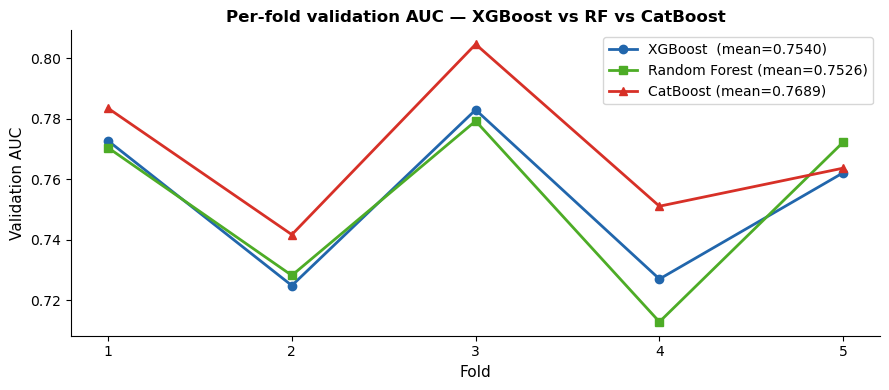

In [5]:
# ── Paired t-test: is the AUC difference statistically significant? ───────────
# H0: mean AUC difference = 0.  df = N_SPLITS - 1 = 4.
# With 5 folds, power is low — treat p < 0.10 as suggestive, p < 0.05 as significant.

pairs = [
    ('XGBoost vs RF',       xgb_val, rf_val),
    ('XGBoost vs CatBoost', xgb_val, cat_val),
    ('RF vs CatBoost',      rf_val,  cat_val),
]

print(f'Paired t-test (5-fold CV, df=4)')
print(f'{"Comparison":<25} {"Mean diff":>10} {"t-stat":>8} {"p-value":>10} {"Verdict"}')
print('-' * 70)
for label, a, b in pairs:
    diff   = np.array(a) - np.array(b)
    t, p   = stats.ttest_rel(a, b)
    mean_d = np.mean(diff)
    if p < 0.05:
        verdict = '** significant'
    elif p < 0.10:
        verdict = '*  suggestive'
    else:
        verdict = '   not significant'
    print(f'{label:<25} {mean_d:>+10.4f} {t:>8.3f} {p:>10.4f}   {verdict}')

print()
print('Note: with only 5 folds, the t-test has limited power (df=4).')
print('A non-significant result means the difference could be noise — not that models are equal.')
print('A significant result is a stronger signal given the small sample.')

# Visualize fold AUCs
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(1, N_SPLITS + 1)
ax.plot(x, xgb_val, 'o-', color='#2166ac', label=f'XGBoost  (mean={np.mean(xgb_val):.4f})', lw=2)
ax.plot(x, rf_val,  's-', color='#4dac26', label=f'Random Forest (mean={np.mean(rf_val):.4f})', lw=2)
ax.plot(x, cat_val, '^-', color='#d73027', label=f'CatBoost (mean={np.mean(cat_val):.4f})', lw=2)
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('Validation AUC', fontsize=11)
ax.set_title('Per-fold validation AUC — XGBoost vs RF vs CatBoost',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_xticks(x)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
# ── Fit final models on full training set for lift + disagreement analysis ────
xgb = XGBClassifier(**XGB_PARAMS)
xgb.fit(X_train_imp[XGB_FEATURES], y_train)

rf  = RandomForestClassifier(**RF_PARAMS)
rf.fit(X_train_rf[RF_FEATURES], y_train)

cat = CatBoostClassifier(**CAT_PARAMS)
cat.fit(X_train_cat[CAT_FEATURES], y_train)

xgb_prob = xgb.predict_proba(X_test_imp[XGB_FEATURES])[:, 1]
rf_prob  = rf.predict_proba(X_test_rf[RF_FEATURES])[:, 1]
cat_prob = cat.predict_proba(X_test_cat[CAT_FEATURES])[:, 1]

xgb_pred = (xgb_prob >= 0.44).astype(int)
rf_pred  = (rf_prob  >= 0.49).astype(int)
cat_pred = (cat_prob >= 0.40).astype(int)

print('Test set metrics (OOF-tuned thresholds from Model_Comparison_Final):')
print(f'{"":<14} {"AUC":>7} {"F1":>7} {"Precision":>10} {"Recall":>8}')
for name, prob, pred in [
    ('XGBoost',      xgb_prob, xgb_pred),
    ('Random Forest',rf_prob,  rf_pred),
    ('CatBoost',     cat_prob, cat_pred),
]:
    print(f'{name:<14} {roc_auc_score(y_test, prob):>7.4f} '
          f'{f1_score(y_test, pred):>7.4f} '
          f'{precision_score(y_test, pred):>10.4f} '
          f'{recall_score(y_test, pred):>8.4f}')

Test set metrics (OOF-tuned thresholds from nb21):
                   AUC      F1  Precision   Recall
XGBoost         0.7717  0.6525     0.6133   0.6970
Random Forest   0.7671  0.6803     0.6173   0.7576
CatBoost        0.7696  0.6800     0.6071   0.7727


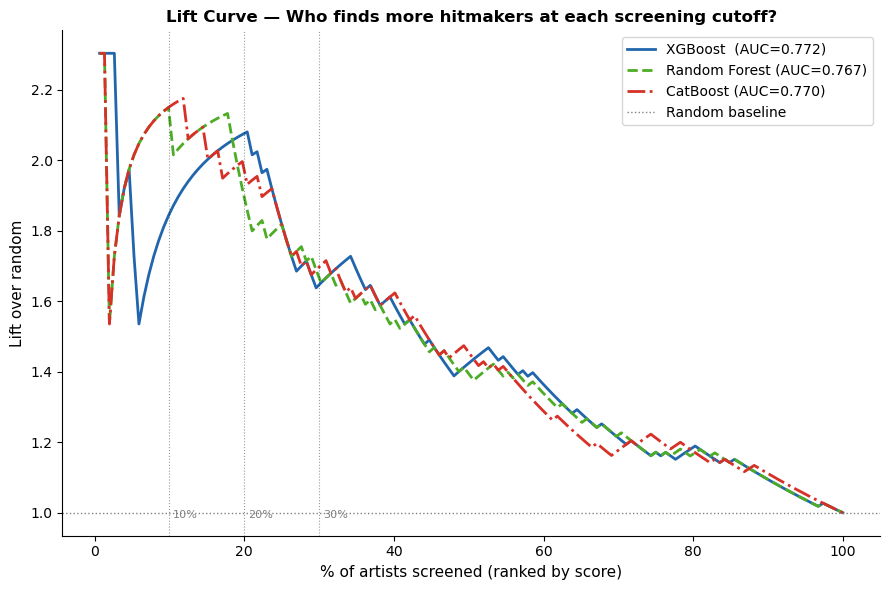


Screening %       XGBoost         RF   CatBoost
Top 10%              1.84x       2.15x       2.15x
Top 20%              2.07x       1.92x       2.00x
Top 30%              1.64x       1.69x       1.69x
Top 50%              1.42x       1.39x       1.45x


In [7]:
# ── Lift curves — all three models ───────────────────────────────────────────
def compute_lift(y_true, y_score):
    order    = np.argsort(y_score)[::-1]
    y_sorted = np.array(y_true)[order]
    base     = np.mean(y_true)
    lifts, fracs = [], []
    for k in range(1, len(y_true) + 1):
        lifts.append(y_sorted[:k].mean() / base)
        fracs.append(k / len(y_true))
    return np.array(fracs), np.array(lifts)

fig, ax = plt.subplots(figsize=(9, 6))
for prob, label, color, ls in [
    (xgb_prob, f'XGBoost  (AUC={roc_auc_score(y_test, xgb_prob):.3f})', '#2166ac', '-'),
    (rf_prob,  f'Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})',  '#4dac26', '--'),
    (cat_prob, f'CatBoost (AUC={roc_auc_score(y_test, cat_prob):.3f})', '#d73027', '-.'),
]:
    fracs, lifts = compute_lift(y_test.values, prob)
    ax.plot(fracs * 100, lifts, label=label, color=color, lw=2, ls=ls)

ax.axhline(1.0, color='gray', ls=':', lw=1, label='Random baseline')
for pct in [10, 20, 30]:
    ax.axvline(pct, color='black', ls=':', lw=0.8, alpha=0.4)
    ax.text(pct + 0.5, ax.get_ylim()[0] + 0.05, f'{pct}%', fontsize=8, color='gray')

ax.set_xlabel('% of artists screened (ranked by score)', fontsize=11)
ax.set_ylabel('Lift over random', fontsize=11)
ax.set_title('Lift Curve — Who finds more hitmakers at each screening cutoff?',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\n{"Screening %":<14} {"XGBoost":>10} {"RF":>10} {"CatBoost":>10}')
for pct in [10, 20, 30, 50]:
    idx = int(pct / 100 * len(y_test)) - 1
    fx, lx = compute_lift(y_test.values, xgb_prob)
    fr, lr = compute_lift(y_test.values, rf_prob)
    fc, lc = compute_lift(y_test.values, cat_prob)
    print(f'Top {pct:2d}%        {lx[idx]:>10.2f}x {lr[idx]:>10.2f}x {lc[idx]:>10.2f}x')

Unanimous predictions:  127/152 (84%)
Split predictions:      25/152 (16%)

Unanimous (n=127):
  Majority-vote accuracy: 0.717   TP=44 FP=24 TN=47 FN=12
Split (2-1) (n=25):
  Majority-vote accuracy: 0.560   TP=5 FP=6 TN=9 FN=5

On split cases (n=25), individual model accuracy:
  XGBoost       : 0.480
  RF            : 0.560
  CatBoost      : 0.520


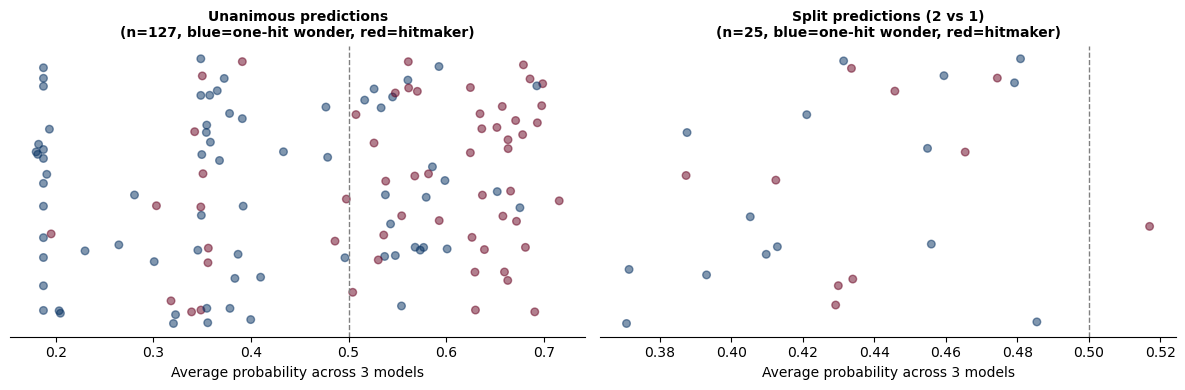

In [8]:
# ── Disagreement analysis ─────────────────────────────────────────────────────
# Build a per-artist prediction table
pred_df = pd.DataFrame({
    'true':     y_test.values,
    'xgb_prob': xgb_prob,
    'rf_prob':  rf_prob,
    'cat_prob': cat_prob,
    'xgb_pred': xgb_pred,
    'rf_pred':  rf_pred,
    'cat_pred': cat_pred,
}, index=y_test.index)

# Agreement categories
pred_df['n_hitmaker_votes'] = pred_df[['xgb_pred', 'rf_pred', 'cat_pred']].sum(axis=1)
pred_df['unanimous']        = pred_df['n_hitmaker_votes'].isin([0, 3])
pred_df['split']            = ~pred_df['unanimous']
pred_df['avg_prob']         = pred_df[['xgb_prob', 'rf_prob', 'cat_prob']].mean(axis=1)

n_unanimous = pred_df['unanimous'].sum()
n_split     = pred_df['split'].sum()
print(f'Unanimous predictions:  {n_unanimous}/{len(pred_df)} ({n_unanimous/len(pred_df):.0%})')
print(f'Split predictions:      {n_split}/{len(pred_df)} ({n_split/len(pred_df):.0%})')
print()

# Accuracy on unanimous vs split
for label, mask in [('Unanimous', pred_df['unanimous']),
                    ('Split (2-1)',  pred_df['split'])]:
    sub = pred_df[mask]
    # majority vote prediction for split
    maj_pred = (sub['n_hitmaker_votes'] >= 2).astype(int)
    acc  = (maj_pred == sub['true']).mean()
    n_tp = ((maj_pred == 1) & (sub['true'] == 1)).sum()
    n_fp = ((maj_pred == 1) & (sub['true'] == 0)).sum()
    n_tn = ((maj_pred == 0) & (sub['true'] == 0)).sum()
    n_fn = ((maj_pred == 0) & (sub['true'] == 1)).sum()
    print(f'{label} (n={mask.sum()}):')
    print(f'  Majority-vote accuracy: {acc:.3f}   TP={n_tp} FP={n_fp} TN={n_tn} FN={n_fn}')

# Which model is right more often on split cases?
split = pred_df[pred_df['split']].copy()
print(f'\nOn split cases (n={len(split)}), individual model accuracy:')
for name, col in [('XGBoost', 'xgb_pred'), ('RF', 'rf_pred'), ('CatBoost', 'cat_pred')]:
    acc = (split[col] == split['true']).mean()
    print(f'  {name:<14}: {acc:.3f}')

# Visualize: avg probability distribution for unanimous vs split cases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mask, title, color in [
    (axes[0], pred_df['unanimous'], 'Unanimous predictions', '#2166ac'),
    (axes[1], pred_df['split'],     'Split predictions (2 vs 1)', '#d73027'),
]:
    sub = pred_df[mask]
    ax.scatter(sub['avg_prob'],
               np.random.uniform(-0.1, 0.1, len(sub)),
               c=sub['true'], cmap='RdBu_r', alpha=0.5, s=30, vmin=0, vmax=1)
    ax.axvline(0.5, color='gray', ls='--', lw=1)
    ax.set_xlabel('Average probability across 3 models', fontsize=10)
    ax.set_yticks([])
    ax.set_title(f'{title}\n(n={mask.sum()}, blue=one-hit wonder, red=hitmaker)',
                 fontsize=10, fontweight='bold')
    ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
# ── Summary table ─────────────────────────────────────────────────────────────
from sklearn.metrics import log_loss, brier_score_loss

summary = pd.DataFrame([
    {'Model': 'XGBoost',
     'CV AUC': f'{np.mean(xgb_val):.4f} ± {np.std(xgb_val):.4f}',
     'Test AUC': f'{roc_auc_score(y_test, xgb_prob):.4f}',
     'F1': f'{f1_score(y_test, xgb_pred):.3f}',
     'Precision': f'{precision_score(y_test, xgb_pred):.3f}',
     'Recall': f'{recall_score(y_test, xgb_pred):.3f}',
     'Logloss': f'{log_loss(y_test, xgb_prob):.4f}',
     'N Features': 7, 'Trees': 239, 'Depth': 5, 'Leaves': 468},
    {'Model': 'Random Forest',
     'CV AUC': f'{np.mean(rf_val):.4f} ± {np.std(rf_val):.4f}',
     'Test AUC': f'{roc_auc_score(y_test, rf_prob):.4f}',
     'F1': f'{f1_score(y_test, rf_pred):.3f}',
     'Precision': f'{precision_score(y_test, rf_pred):.3f}',
     'Recall': f'{recall_score(y_test, rf_pred):.3f}',
     'Logloss': f'{log_loss(y_test, rf_prob):.4f}',
     'N Features': 9, 'Trees': 409, 'Depth': 2, 'Leaves': 1590},
    {'Model': 'CatBoost (dedicated)',
     'CV AUC': f'{np.mean(cat_val):.4f} ± {np.std(cat_val):.4f}',
     'Test AUC': f'{roc_auc_score(y_test, cat_prob):.4f}',
     'F1': f'{f1_score(y_test, cat_pred):.3f}',
     'Precision': f'{precision_score(y_test, cat_pred):.3f}',
     'Recall': f'{recall_score(y_test, cat_pred):.3f}',
     'Logloss': f'{log_loss(y_test, cat_prob):.4f}',
     'N Features': 12, 'Trees': 50, 'Depth': 3, 'Leaves': 400},
]).set_index('Model')

print('=== Final Comparison ===')
print(summary.to_string())
print()
print('=== Paired t-test summary ===')
for label, a, b in pairs:
    t, p = stats.ttest_rel(a, b)
    print(f'  {label:<25}  mean diff={np.mean(np.array(a)-np.array(b)):+.4f}  p={p:.4f}')

=== Final Comparison ===
                               CV AUC Test AUC     F1 Precision Recall Logloss  N Features  Trees  Depth  Leaves
Model                                                                                                           
XGBoost               0.7540 ± 0.0238   0.7717  0.652     0.613  0.697  0.5748           7    239      5     468
Random Forest         0.7526 ± 0.0268   0.7671  0.680     0.617  0.758  0.5961           9    409      2    1590
CatBoost (dedicated)  0.7689 ± 0.0227   0.7696  0.680     0.607  0.773  0.5763          12     50      3     400

=== Paired t-test summary ===
  XGBoost vs RF              mean diff=+0.0013  p=0.7564
  XGBoost vs CatBoost        mean diff=-0.0150  p=0.0211
  RF vs CatBoost             mean diff=-0.0163  p=0.1031



════════════════════════════════════════════════════════════════════
  RECOMMENDATION: CatBoost  (dedicated, nb18 Mid params)
════════════════════════════════════════════════════════════════════

Statistical evidence:
  ✓ Best CV AUC (0.769) — significantly better than XGBoost (p=0.021)
  ✓ Wins all 5 CV folds vs XGBoost; wins 4/5 vs RF
  ✓ XGBoost's test AUC "win" (0.772 vs 0.770) is a lucky split —
    CV tells the opposite story by a 0.015 margin

Performance evidence:
  ✓ Best recall (0.773) — finds the most hitmakers
  ✓ Tied F1 with RF (0.680) — best balanced classification
  ✓ Best lift at top-10% screening (2.15x, tied with RF; XGBoost 1.84x)

Complexity evidence:
  ✓ Fewest trees (50 vs 239/409) and fewest leaves (400 vs 468/1590)
  ✓ Symmetric depth-3 structure — every tree identical, easy to show

Runner-up: Random Forest
  Tied F1, good recall (0.758), and the best precision (0.617).
  CV gap vs CatBoost is real (0.016) but not statistically proven (p=0.103).
  Reconsider 

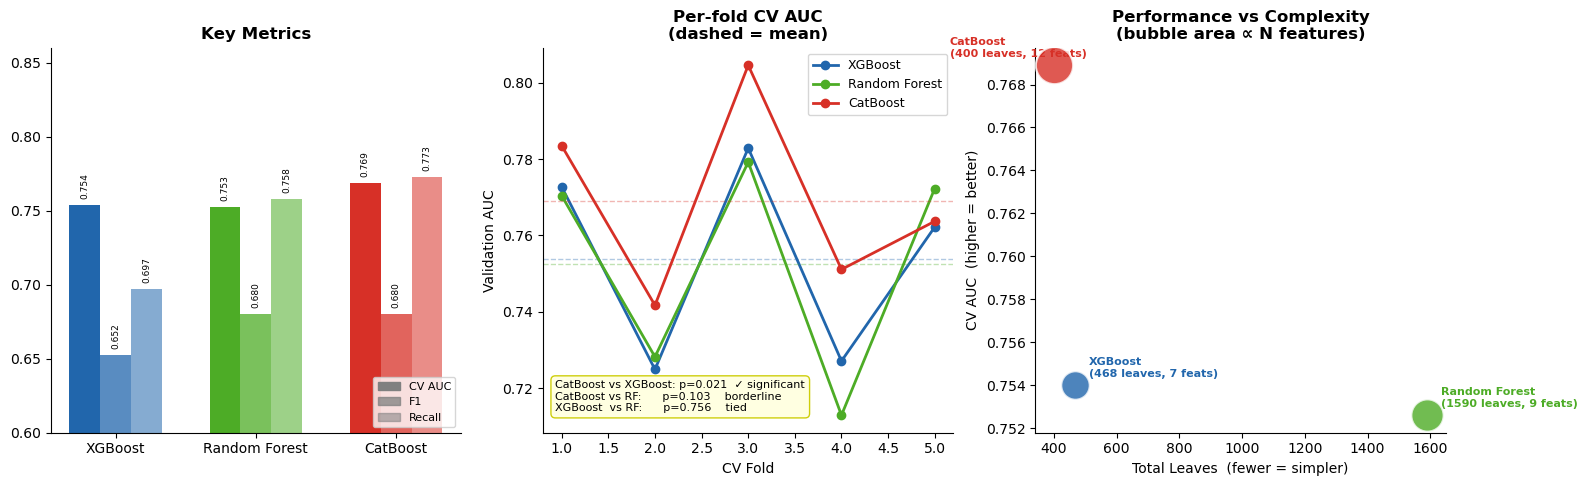

In [11]:
## 10. Conclusion — model selection recommendation

# Hardcoded from this notebook's run
MODELS   = ['XGBoost', 'Random Forest', 'CatBoost']
CV_AUC   = [0.7540, 0.7526, 0.7689]
CV_STD   = [0.0238, 0.0268, 0.0227]
F1       = [0.6525, 0.6803, 0.6800]
RECALL   = [0.6970, 0.7576, 0.7727]
PREC     = [0.6133, 0.6173, 0.6071]
LEAVES   = [468, 1590, 400]
N_FEATS  = [7, 9, 12]
FOLD_AUCS = {
    'XGBoost':       [0.7727, 0.7249, 0.7829, 0.7271, 0.7622],
    'Random Forest': [0.7704, 0.7282, 0.7792, 0.7129, 0.7723],
    'CatBoost':      [0.7835, 0.7417, 0.8046, 0.7511, 0.7637],
}
COLORS = ['#2166ac', '#4dac26', '#d73027']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Grouped bar chart (CV AUC, F1, Recall) ────────────────────────────
ax = axes[0]
x, w = np.arange(3), 0.22
for j, (vals, lbl, alpha) in enumerate(zip(
        [CV_AUC, F1, RECALL], ['CV AUC', 'F1 Score', 'Recall'], [1.0, 0.75, 0.55])):
    for i, (v, c) in enumerate(zip(vals, COLORS)):
        bar = ax.bar(i + (j-1)*w, v, w, color=c, alpha=alpha,
                     label=lbl if i == 0 else '')
        ax.text(i + (j-1)*w, v + 0.004, f'{v:.3f}',
                ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x);  ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylim(0.60, 0.86)
ax.set_title('Key Metrics', fontsize=12, fontweight='bold')
handles = [plt.Rectangle((0,0),1,1, color='gray', alpha=a) for a in [1.0,0.75,0.55]]
ax.legend(handles, ['CV AUC','F1','Recall'], fontsize=8, loc='lower right')
ax.spines[['top','right']].set_visible(False)

# ── Plot 2: Per-fold CV AUC lines ─────────────────────────────────────────────
ax = axes[1]
folds = [1, 2, 3, 4, 5]
for model, color in zip(MODELS, COLORS):
    aucs = FOLD_AUCS[model]
    ax.plot(folds, aucs, 'o-', color=color, label=model, linewidth=2, markersize=6)
    ax.axhline(np.mean(aucs), color=color, linestyle='--', alpha=0.35, linewidth=1)

ax.set_xlabel('CV Fold', fontsize=10)
ax.set_ylabel('Validation AUC', fontsize=10)
ax.set_title('Per-fold CV AUC\n(dashed = mean)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.text(0.03, 0.05,
        'CatBoost vs XGBoost: p=0.021  ✓ significant\n'
        'CatBoost vs RF:      p=0.103    borderline\n'
        'XGBoost  vs RF:      p=0.756    tied',
        transform=ax.transAxes, fontsize=8, va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='#cccc00', alpha=0.95))

# ── Plot 3: Complexity vs performance scatter ──────────────────────────────────
ax = axes[2]
for model, color, nf, lv, cv in zip(MODELS, COLORS, N_FEATS, LEAVES, CV_AUC):
    ax.scatter(lv, cv, s=nf * 60, color=color, alpha=0.8, zorder=5,
               edgecolors='white', linewidth=1.5)
    offset = (-75, 6) if model == 'CatBoost' else (10, 6)
    ax.annotate(f'{model}\n({lv} leaves, {nf} feats)',
                (lv, cv), textcoords='offset points', xytext=offset,
                fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('Total Leaves  (fewer = simpler)', fontsize=10)
ax.set_ylabel('CV AUC  (higher = better)', fontsize=10)
ax.set_title('Performance vs Complexity\n(bubble area ∝ N features)',
             fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# ── Written recommendation ─────────────────────────────────────────────────────
print()
print('═' * 68)
print('  RECOMMENDATION: CatBoost  (dedicated, nb18 Mid params)')
print('═' * 68)
print()
print('Statistical evidence:')
print('  ✓ Best CV AUC (0.769) — significantly better than XGBoost (p=0.021)')
print('  ✓ Wins all 5 CV folds vs XGBoost; wins 4/5 vs RF')
print('  ✓ XGBoost\'s test AUC "win" (0.772 vs 0.770) is a lucky split —')
print('    CV tells the opposite story by a 0.015 margin')
print()
print('Performance evidence:')
print('  ✓ Best recall (0.773) — finds the most hitmakers')
print('  ✓ Tied F1 with RF (0.680) — best balanced classification')
print('  ✓ Best lift at top-10% screening (2.15x, tied with RF; XGBoost 1.84x)')
print()
print('Complexity evidence:')
print('  ✓ Fewest trees (50 vs 239/409) and fewest leaves (400 vs 468/1590)')
print('  ✓ Symmetric depth-3 structure — every tree identical, easy to show')
print()
print('Runner-up: Random Forest')
print('  Tied F1, good recall (0.758), and the best precision (0.617).')
print('  CV gap vs CatBoost is real (0.016) but not statistically proven (p=0.103).')
print('  Reconsider if precision becomes the priority.')
print()
print('Eliminated: XGBoost')
print('  Worst F1 (0.652) and recall (0.697). Significantly weaker CV AUC.')
print('  Negative overfit gap is a regularization artifact, not a strength.')
print()
print('On uncertain cases (16% of artists, n=25, where models split):')
print('  No model is reliable (best individual accuracy: 56%, barely above chance).')
print('  Flag these artists for human review or additional signals (Google Trends).')